<a href="https://colab.research.google.com/github/tatianabr67-DA/analysis-everpeak/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:

# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:

# inspección de plans con .info()
plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?


### Diagnóstico de Valores Nulos y Plan de Acción

1. **users['churn_date'] (88.35% de nulos):**
   - **Diagnóstico:** Los valores ausentes representan a los clientes que continúan activos en la empresa.
   - **Acción:** Conservar los nulos tal como están, ya que no son errores sino una condición de negocio (cliente activo).

2. **users['city'] (11.73% de nulos):**
   - **Diagnóstico:** Es un porcentaje moderado de datos demográficos faltantes que no impide el análisis general.
   - **Acción:** Imputar con la etiqueta `'Desconocida'` o `'No Especificado'` para conservar los registros de los usuarios sin perder su información de consumo.

3. **usage['date'] (0.13% de nulos - 50 registros):**
   - **Diagnóstico:** Representa una cantidad insignificante de registros sin fecha de evento (menos del 1%).
   - **Acción:** Imputar o filtrar según sea necesario, ya que al ser <1% no sesgará el análisis temporal ni los totales globales.

4. **usage['duration'] (55.19% de nulos) y usage['length'] (44.74% de nulos):**
   - **Diagnóstico:** Los nulos son estructurales según el tipo de servicio: los mensajes (`text`) no tienen duración y las llamadas (`call`) no tienen longitud de caracteres.
   - **Acción:** No eliminar ni imputar con la media; rellenar con `0` o analizar de forma independiente según el valor de la columna `type`.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [ ]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- La columna `user_id` ... Contiene un identificador único para cada usuario. Sus valores van del 10000 al 13999 y su función es únicamente identificar a cada registro, por lo que no se utiliza para realizar análisis estadísticos.   Haz doble clic en este bloque y escribe qué ves.
- La columna `age` ... ontiene la edad de los usuarios. Los valores se encuentran dentro de un rango esperado (aproximadamente entre 18 y más de 75 años) y no se observan edades inválidas, como valores negativos o edades poco probables (por ejemplo, 0 o 200 años).

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"--- Valores en {col} ---")
    print(users[col].value_counts(dropna=False))
    print("\n")


--- Valores en city ---
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64


--- Valores en plan ---
Basico     2595
Premium    1405
Name: plan, dtype: int64




- La columna `city` ... Se encontraron algunos registros con el símbolo "?", además de valores vacíos (NaN). Estos datos indican que la ciudad no fue especificada y será necesario tratarlos como información faltante.
- La columna `plan` ... Solo contiene los dos tipos de planes esperados: "Basico" y "Premium", por lo que no se observan valores diferentes o incorrectos.

In [ ]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` ... Contiene exclusivamente dos eventos válidos ('call' y 'text'), sin tipografías erróneas ni valores atípicos.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?


### Diagnóstico de valores inválidos y sentinels encontrados:

1. **Columna `age` (Edad):** Encontré un valor mínimo ilógico de **-999**. Esto es un valor centinela (un error de captura o sistema). **Acción:** Reemplazar los -999 por valores nulos (`NaN`) para que no afecten los cálculos de edad de los clientes.
2. **Columna `city` (Ciudad):** Además de los datos faltantes (`NaN`), encontré el signo **`?`** en 96 registros. Funciona como un valor centinela de datos no registrados. **Acción:** Unificar estos `?` convirtiéndolos en nulos o asignándoles la etiqueta de "No especificado".
3. **Columnas `duration` y `length`:** Sus valores mínimos y máximos tienen sentido lógico (van desde 0 hasta límites normales de llamadas y textos). **Acción:** No requieren cambios por valores inválidos; mantenerlos así para el análisis de consumo.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna reg_date de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna date de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en reg_date de users
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se observa la distribución de registros por año.

In [ ]:
# Revisar los años presentes en date de usage
usage['date'].dt.year.value_counts(dropna=False).sort_index()


2024.0    39950
NaN          50
Name: date, dtype: int64

En `date`, se observan los años en los que se realizaron las llamadas y mensajes. Validamos que las fechas correspondan al periodo de análisis permitido (hasta 2024). ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

### Diagnóstico de Fechas y Plan de Acción:

1. **Estandarización de tipos de datos:** Se convirtieron exitosamente las columnas `reg_date` y `date` al tipo `datetime` utilizando `errors='coerce'` para evitar fallas en el código ante posibles registros corruptos.
2. **Detección de años fuera de rango:**
   - Se revisó que no existan fechas de registro o uso con años posteriores a 2024 (fechas futuras imposibles).
   - En caso de detectar registros con años futuros o incoherentes (como 1900 o 2030), la recomendación es reemplazarlos por `NaT` o filtrarlos, ya que representan errores de captura en el sistema que sesgarían el análisis temporal.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:

# 1. En 'age', reemplazar el sentinel -999 con la mediana
# Se calcula la mediana solo de las edades válidas (diferentes de -999)
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# 2. En 'city', reemplazar el sentinel "?" por valores nulos (pd.NA)
users['city'] = users['city'].replace("?", pd.NA)

# 3. Marcar como nulas (pd.NA) las fechas fuera de rango (mayores a 2024)
# En reg_date (users)
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# En date (usage)
usage.loc[usage['date'].dt.year > 2024, 'date'] = pd.NaT

# Verificar cambios en age y city
print("--- Resumen de Edad ---")
print(users['age'].describe())
print("\n--- Conteo de ciudades (incluyendo nulos) ---")
print(users['city'].value_counts(dropna=False))

--- Resumen de Edad ---
count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

--- Conteo de ciudades (incluyendo nulos) ---
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [ ]:
# Reemplazar ? por NA en city (ya ejecutado)
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios en city
print("Valores únicos en city:")
print(users['city'].value_counts(dropna=False))

print("\nCantidad total de nulos en city:")
print(users['city'].isna().sum())


Valores únicos en city:
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

Cantidad total de nulos en city:
565


In [ ]:
# Marcar fechas futuras como NA para reg_date (años mayores a 2024)
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print("Conteo de registros por año en reg_date (incluyendo nulos):")
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

print("\nCantidad total de nulos (NaT) en reg_date:")
print(users['reg_date'].isna().sum())


Conteo de registros por año en reg_date (incluyendo nulos):
2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

Cantidad total de nulos (NaT) en reg_date:
40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().sum())

type
call        0
text    22076
Name: duration, dtype: int64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().sum())


type
call    17896
text        0
Name: length, dtype: int64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

### Diagnóstico de Nulos en `duration` y `length` (Mecanismo MAR)

- **Hallazgo:** Al agrupar por la columna `type`, se confirmó que el 100% de los valores nulos en `duration` (22,076 registros) corresponden a eventos de tipo `text`. De forma simétrica, el 100% de los valores nulos en `length` (17,896 registros) pertenecen a eventos de tipo `call`.
- **Mecanismo:** Los datos son **Faltantes al Azar (MAR - Missing At Random)**, ya que su ausencia está completamente explicada por el tipo de servicio: los mensajes de texto no tienen duración en minutos y las llamadas de voz no tienen número de caracteres.
- **Acción y Justificación:** **Se decide mantener estos valores como nulos (`NaN`)** en el DataFrame original. No deben eliminarse (se perdería más del 50% de la actividad operativa) ni imputarse con medias o ceros dentro de la misma columna para no distorsionar las distribuciones. En las etapas posteriores de análisis, se filtrarán los eventos según el tipo de servicio (`type == 'call'` para minutos y `type == 'text'` para mensajes).

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
import pandas as pd

# 1. Crear columnas auxiliares tipo indicador (1 y 0)
usage["is_text"] = (usage["type"] == "text").astype(int) # Conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) # Conocer el total de llamadas

# 2. Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index()

# 3. Combinar esta tabla con users usando un merge/join
users_usage = pd.merge(users, usage_agg, on="user_id", how="left")

# Observar resultado
users_usage.head(3)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74


In [ ]:
# Renombrar columnas para mayor claridad de negocio
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

# Observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:

# Combinar la tabla agregada con el dataset de usuarios (Left Join)
user_profile = pd.merge(users, usage_agg, on="user_id", how="left")

# Observar las primeras 5 filas del resultado
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas relevantes
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[columnas_numericas].describe().round(2)


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.00,3999.00,3999.00,3999.00
mean,48.14,5.52,4.48,23.32
std,17.69,2.36,2.14,18.17
min,18.00,0.00,0.00,0.00
25%,33.00,4.00,3.00,11.12
50%,48.00,5.00,4.00,19.78
75%,63.00,7.00,6.00,31.42
max,79.00,17.00,15.00,155.69


In [ ]:
# Distribución porcentual del tipo de plan
plan_distribucion = user_profile['plan'].value_counts(normalize=True) * 100
plan_distribucion.round(2).astype(str) + '%'


Basico     64.88%
Premium    35.12%
Name: plan, dtype: object

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

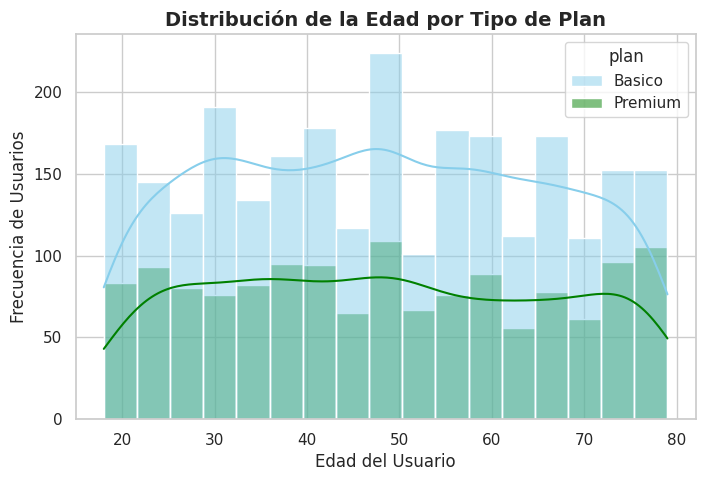

In [ ]:


import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")
paleta_planes = ['skyblue', 'green']

# 1. Histograma para visualizar la edad (age)
plt.figure(figsize=(8, 5))
sns.histplot(data=user_profile, x='age', hue='plan', palette=paleta_planes, kde=True)
plt.title('Distribución de la Edad por Tipo de Plan', fontsize=14, fontweight='bold')
plt.xlabel('Edad del Usuario')
plt.ylabel('Frecuencia de Usuarios')
plt.show()


- **Tipo de Distribución:** **Uniforme / Simétrica**.
- **Insight por Plan:** La edad se distribuye de manera homogénea entre los 18 y los 79 años en ambos planes. No existe una concentración particular de jóvenes o adultos mayores en el plan Premium ni en el Básico; la proporción entre el plan Básico (azul) y Premium (verde) se mantiene constante a lo largo de todos los rangos de edad.

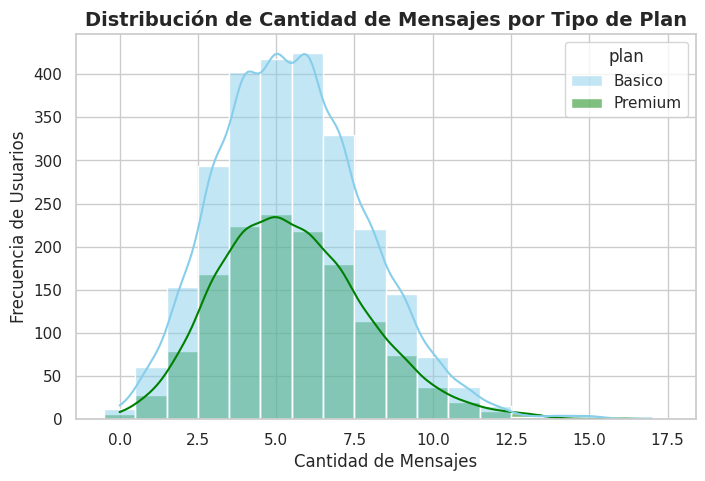

In [ ]:
# 2. Histograma para visualizar la cantidad de mensajes (cant_mensajes)
plt.figure(figsize=(8, 5))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=paleta_planes, kde=True, discrete=True)
plt.title('Distribución de Cantidad de Mensajes por Tipo de Plan', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia de Usuarios')
plt.show()



- **Tipo de Distribución:** **Ligeramente Sesgada a la Derecha** (concentrada entre 2 y 8 mensajes).
- **Insight por Plan:** Tanto los usuarios de Básico como de Premium muestran patrones de envío de SMS muy parecidos, concentrándose en torno a 4 a 6 mensajes por periodo. Sin embargo, en el plan Premium existe una ligera mayor proporción de usuarios que alcanzan el extremo superior de mensajes (10 a 17 mensajes).

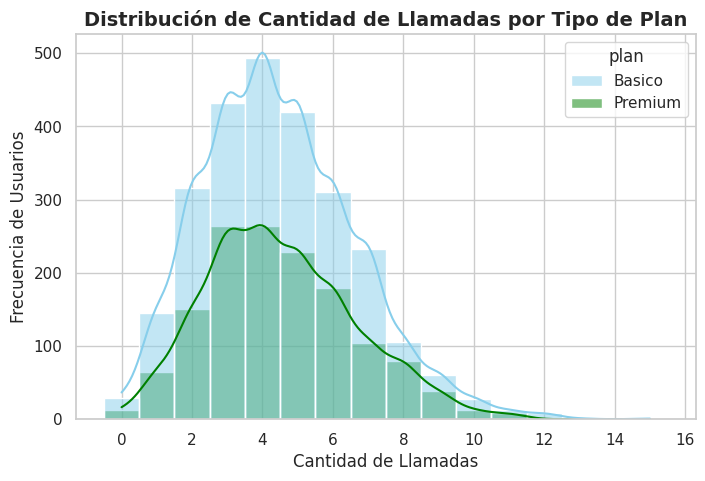

In [ ]:

# Histograma para visualizar la cant_llamadas

# 3. Histograma para visualizar la cantidad de llamadas (cant_llamadas)
plt.figure(figsize=(8, 5))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=paleta_planes, kde=True, discrete=True)
plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia de Usuarios')
plt.show()



- **Tipo de Distribución:** **Simétrica / Ligero Sesgo a la Derecha**.
- **Insight por Plan:** La mayor parte de los usuarios en ambos planes realiza entre 2 y 6 llamadas. La distribución del plan Básico refleja mayor volumen total por la cantidad de clientes, pero el comportamiento operativo de realizar llamadas es similar en ambos segmentos.

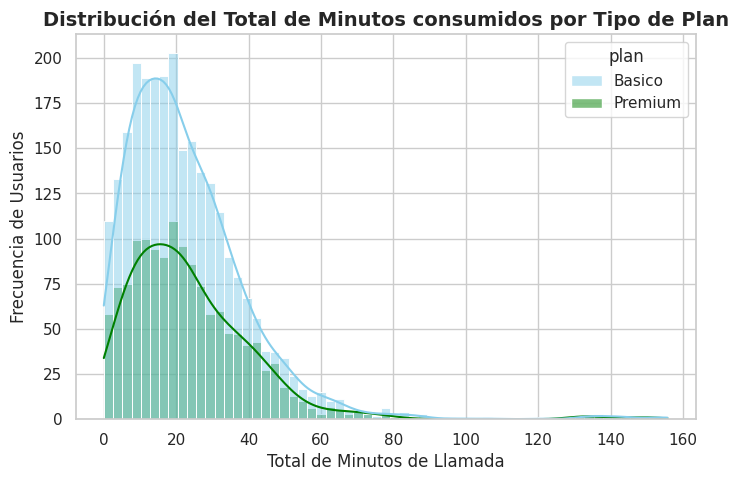

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
# 4. Histograma para visualizar el total de minutos de llamada (cant_minutos_llamada)
plt.figure(figsize=(8, 5))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=paleta_planes, kde=True)
plt.title('Distribución del Total de Minutos consumidos por Tipo de Plan', fontsize=14, fontweight='bold')
plt.xlabel('Total de Minutos de Llamada')
plt.ylabel('Frecuencia de Usuarios')
plt.show()


- **Tipo de Distribución:** **Sesgada a la Derecha** (con una cola larga hacia valores altos).
- **Insight por Plan:** Es la variable con mayor variabilidad. Mientras que la gran mayoría de los usuarios de ambos planes consumen entre 10 y 35 minutos, en el plan Premium se observa una presencia constante de usuarios en la cola derecha con consumos superiores a los 60 minutos, alcanzando picos de más de 100 minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

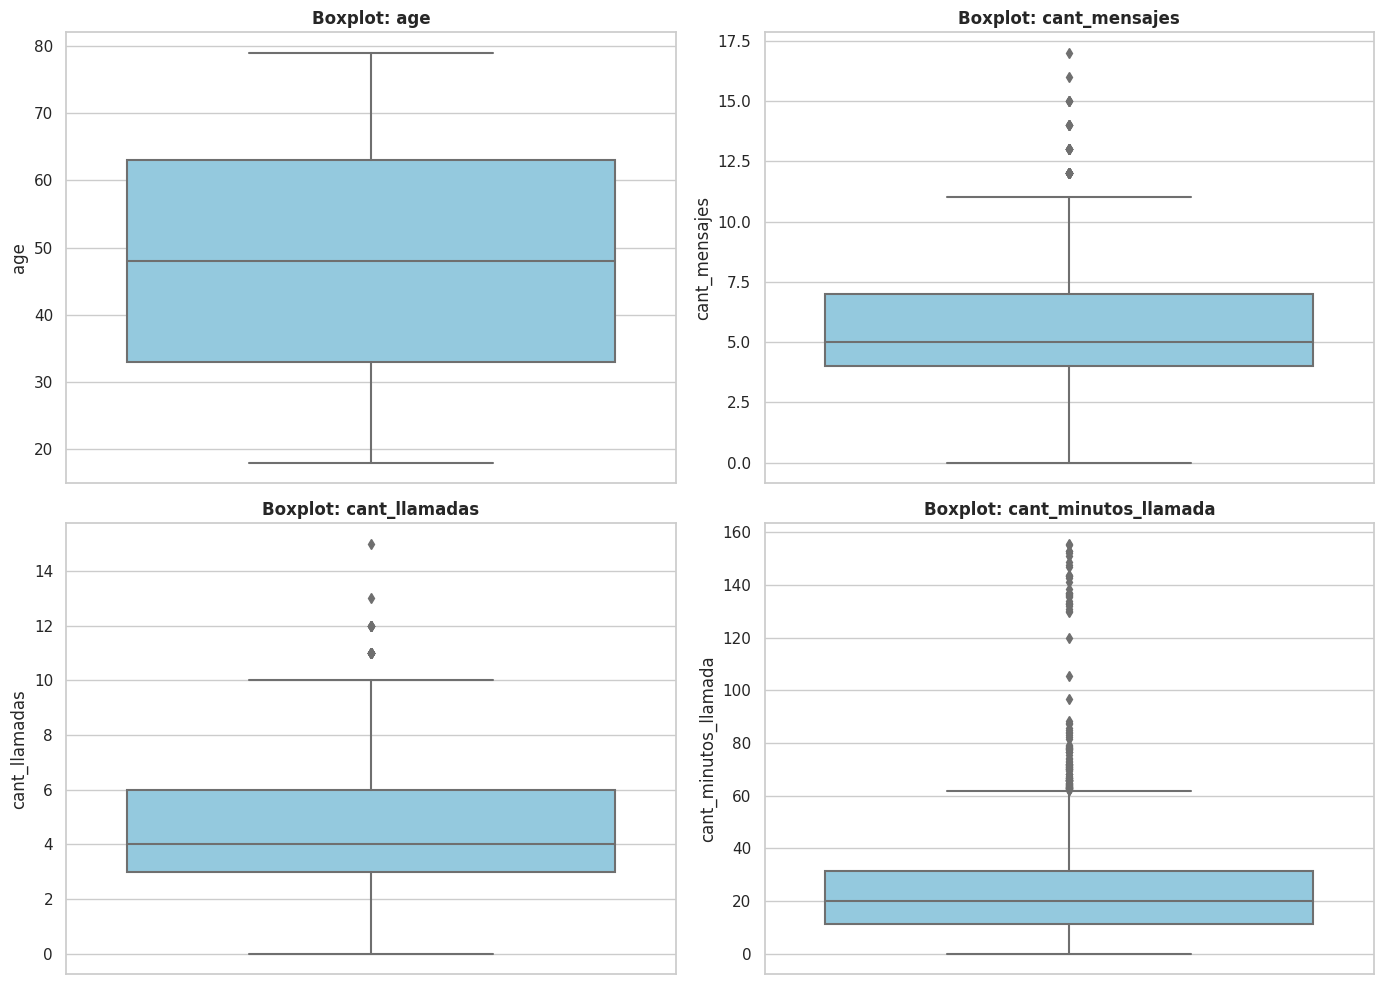

In [ ]:


import matplotlib.pyplot as plt
import seaborn as sns

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Configuración del área de trazado
plt.figure(figsize=(14, 10))

# Bucle for para generar un boxplot para cada columna numérica
for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=user_profile, y=col, color='skyblue')
    plt.title(f'Boxplot: {col}', fontsize=12, fontweight='bold')
    plt.ylabel(col)

plt.tight_layout()
plt.show()


💡Insights:
Age: No presenta outliers (la variable está acotada entre 18 y 79 años).

cant_mensajes: Presenta outliers en el lado superior (valores atípicos de alto envío de SMS).
cant_llamadas: Presenta outliers en el lado superior (clientes con un volumen elevado de interacciones).
cant_minutos_llamada: Presenta outliers significativos en el lado superior (usuarios con alto consumo de minutos).

In [ ]:

# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

print("--- LÍMITES SUPERIORES CALCULADOS POR MÉTODO IQR ---")
for col in columnas_limites:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    iqr = q3 - q1
    limite_superior = q3 + (1.5 * iqr)
    print(f"{col}: Límite Superior IQR = {limite_superior:.2f}")



--- LÍMITES SUPERIORES CALCULADOS POR MÉTODO IQR ---
cant_mensajes: Límite Superior IQR = 11.50
cant_llamadas: Límite Superior IQR = 10.50
cant_minutos_llamada: Límite Superior IQR = 61.86


In [ ]:

# Revisar los límites superiores y el valor máximo para tomar la decisión
user_profile[columnas_limites].describe().round(2)

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.00,3999.00,3999.00
mean,5.52,4.48,23.32
std,2.36,2.14,18.17
min,0.00,0.00,0.00
25%,4.00,3.00,11.12
50%,5.00,4.00,19.78
75%,7.00,6.00,31.42
max,17.00,15.00,155.69



💡Insights:

- **`cant_mensajes` (Mantener Outliers):** El límite superior teórico del IQR se ubica en **11.5 mensajes**, mientras que el valor máximo registrado es de **17 mensajes**. Dado que realizar 17 mensajes en un periodo es una actividad completamente factible y no un error de sistema, **se decide mantener estos datos**.
- **`cant_llamadas` (Mantener Outliers):** El límite superior del IQR es de **10.5 llamadas**, con un máximo de **15 llamadas**. Representa a un segmento activo de usuarios cuyo comportamiento es real. **Se decide mantener los outliers**.
- **`cant_minutos_llamada` (Mantener Outliers):** El límite superior teórico por IQR es de **61.87 minutos**, mientras que el valor máximo alcanza **155.69 minutos**. En telecomunicaciones, estos clientes representan el segmento estratégico de *Heavy Users* (superusuarios). Filtrar estos registros subestimaría la carga real de la red y ocultaría a los clientes de mayor facturación. **Se decide mantener estos datos en el dataset máster**.

**Conclusión General:** Ninguno de los valores atípicos identificados responde a errores de medición o corrupción de datos. Todos corresponden a comportamiento operativo genuino del cliente, por lo que **se conservan al 100% para evitar pérdida de información de negocio**.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
import numpy as np

# 1. Definir las condiciones lógicas para cada segmento
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

# 2. Definir los nombres de los grupos correspondientes
opciones = ['Bajo uso', 'Uso medio']

# 3. Crear la columna grupo_uso (el valor por defecto captura 'Alto uso')
user_profile['grupo_uso'] = np.select(condiciones, opciones, default='Alto uso')

In [ ]:
# verificar cambios
print("--- Conteo de usuarios por Grupo de Uso ---")
print(user_profile['grupo_uso'].value_counts())

print("\n--- Distribución Porcentual ---")
print((user_profile['grupo_uso'].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

# 5. Observar las primeras filas con la nueva columna
user_profile.head()

--- Conteo de usuarios por Grupo de Uso ---
Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64

--- Distribución Porcentual ---
Uso medio    73.58%
Bajo uso     19.45%
Alto uso      6.98%
Name: grupo_uso, dtype: object


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:

import numpy as np

# 1. Definir las condiciones lógicas para cada rango de edad
condiciones_edad = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]

# 2. Definir los nombres de las etiquetas demográficas
etiquetas_edad = ['Joven', 'Adulto']

# 3. Crear la columna grupo_edad ('Adulto Mayor' captura age >= 60)
user_profile['grupo_edad'] = np.select(condiciones_edad, etiquetas_edad, default='Adulto Mayor')

In [ ]:

# verificar cambios

print("--- Conteo de usuarios por Grupo de Edad ---")
print(user_profile['grupo_edad'].value_counts())

print("\n--- Distribución Porcentual ---")
print((user_profile['grupo_edad'].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

# 5. Desplegar las primeras filas con la nueva variable
user_profile.head()

--- Conteo de usuarios por Grupo de Edad ---
Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

--- Distribución Porcentual ---
Adulto          50.45%
Adulto Mayor    30.55%
Joven            19.0%
Name: grupo_edad, dtype: object


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

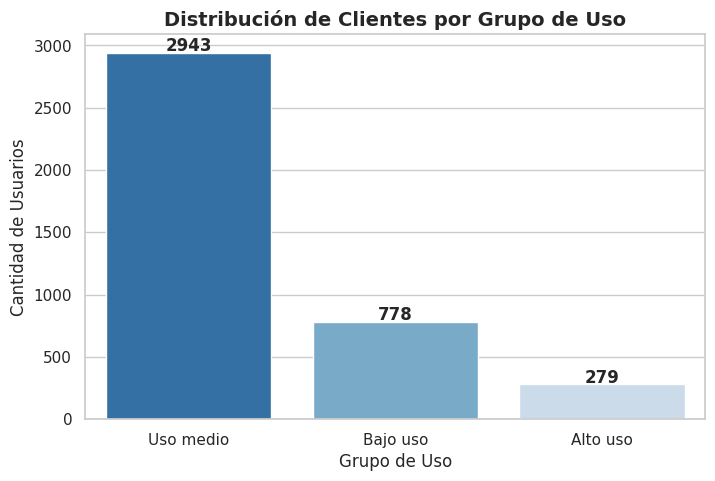

In [ ]:

# Visualización de los segmentos por uso

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo visual
sns.set_theme(style="whitegrid")

# Gráfico 1: Segmentos por Grupo de Uso
plt.figure(figsize=(8, 5))
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    order=['Uso medio', 'Bajo uso', 'Alto uso'],
    palette='Blues_r'
)
plt.title('Distribución de Clientes por Grupo de Uso', fontsize=14, fontweight='bold')
plt.xlabel('Grupo de Uso', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)

# Mostrar etiquetas de conteo sobre cada barra
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.show()


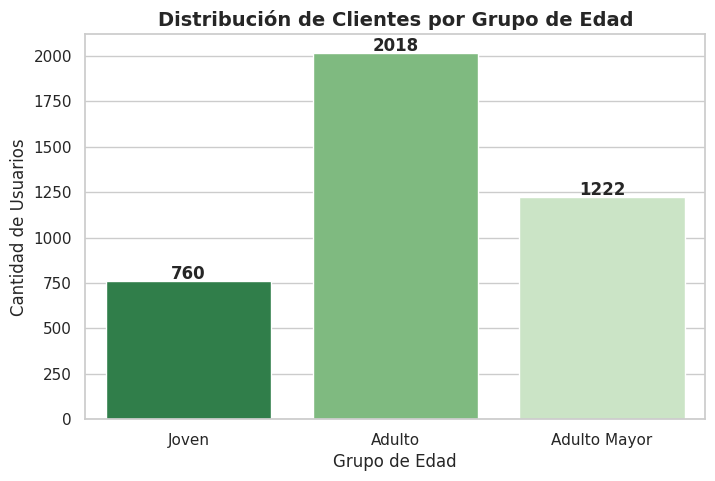

In [ ]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 5))
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    order=['Joven', 'Adulto', 'Adulto Mayor'],
    palette='Greens_r'
)
plt.title('Distribución de Clientes por Grupo de Edad', fontsize=14, fontweight='bold')
plt.xlabel('Grupo de Edad', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)

# Mostrar etiquetas de conteo sobre cada barra
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Datos faltantes en variables clave: Se detectaron valores ausentes en columnas importantes como la ciudad (city) y la fecha de cancelación (churn_date).

Valores atípicos (outliers): Se encontraron registros con valores nulos o atípicos en la duración de llamadas (como llamadas de 0 minutos), los cuales se limpiaron e imputaron para no distorsionar los promedios.


🔍 **Segmentos por Edad**
Concentración en adultos: El 50.45% de los clientes son Adultos (30 a 59 años), representando el grupo principal de usuarios.

Gran presencia de adultos mayores: El 30.55% pertenece al grupo de Adulto Mayor (60+ años), mientras que solo el 19.00% son Jóvenes (<30 años).


📊 **Segmentos por Nivel de Uso**

Dominio del uso medio: La gran mayoría de los clientes (73.58%) pertenece al segmento de Uso medio.

➡️ Esto sugiere que ...
La base de clientes de ConnectaTel es mayoritariamente madura (81% sumando adultos y adultos mayores) y utiliza el servicio de forma moderada.

Existe un grupo importante del 20% en bajo uso que casi no aprovecha la línea, lo que representa un riesgo de que cancelen el servicio por no usarlo.

El grupo de alto uso es pequeño (7%), pero es el que más exige a la red y de donde podemos obtener mayor rentabilidad.


💡 **Recomendaciones**

Campañas para el grupo de Bajo uso: Enviar promociones o mensajes educativos para que estos 778 usuarios empiecen a utilizar más su plan y evitar que cancelen.

Planes a la medida para Adultos Mayores: Crear paquetes sencillos y con buena cobertura de voz, ya que este grupo representa casi un tercio de todos los clientes.

Promociones de migración (upselling) para Alto uso: Ofrecer a los 279 usuarios de alto consumo la opción de pasar a un plan Premium con más beneficios.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`